<a href="https://colab.research.google.com/github/Lucaschewitch/Machine-Learning/blob/main/%D0%9F%D0%A010.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Практическая работа №10. Разведочный анализ, предобработка данных и обучение моделей классификации**

*(на примере датасета Bank Marketing)*

---

## ****Введение****

**Цель работы:** Обучить модель машинного обучения для предсказания, откроет ли клиент банка срочный вклад по результатам маркетинговой кампании (целевая переменная `y`: "yes" — откроет, "no" — не откроет).

**Датасет:** [Bank Marketing Dataset](https://archive.ics.uci.edu/dataset/222/bank+marketing) — данные о маркетинговых кампаниях португальского банка.

**Что вы научитесь делать:**
- Загружать и исследовать данные
- Выявлять проблемы через разведочный анализ (EDA)
- Анализировать и обрабатывать пропущенные значения
- Формулировать и **экспериментально проверять** гипотезы
- Создавать новые признаки (Feature Engineering)
- **Сравнивать все изученные методы классификации**
- **Выбирать лучшие модели и оптимизировать их гиперпараметры с помощью GridSearchCV**
- **Анализировать влияние комбинаций признаков на качество модели**

---

## ****Часть 1. Настройка окружения****

> 📚 **Подсказка:** Аналогичная настройка рассматривалась в [**Занятии 1, Часть 1** и **Занятии 2, Часть 1**](https://colab.research.google.com/drive/1Cnp7hPUUu5dorlhPPHUeztnnoq5Z2j4W?usp=sharing#scrollTo=5f49d9aa).

In [1]:
# Импорт библиотек
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                            f1_score, roc_auc_score, roc_curve, confusion_matrix,
                            classification_report)

# Модели классификации
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (RandomForestClassifier, GradientBoostingClassifier,
                              AdaBoostClassifier)
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB

# Отбор признаков
from sklearn.feature_selection import RFE, SelectKBest, f_classif
from itertools import combinations

# Настройки отображения
sns.set_style("whitegrid")
pd.set_option('display.max_columns', 20)

---

## ****Часть 2. Загрузка и первичный осмотр данных****

> 📚 **Подсказка:** Методы первичного осмотра (`head()`, `info()`, `describe()`, `shape`) подробно разобраны в [**Занятии 1, Часть 3.2**](https://colab.research.google.com/drive/1Cnp7hPUUu5dorlhPPHUeztnnoq5Z2j4W?usp=sharing#scrollTo=9ef7543b) и [**Занятии 2, Часть 2.1**](https://colab.research.google.com/drive/1aT36P0Jc-dIjYOx6Hh8yecFSgt-z3Fan?usp=sharing#scrollTo=43b439e3).

### ****Задание 2.1. Загрузите датасет****

In [2]:
# Загрузка датасета Bank Marketing
url = "https://raw.githubusercontent.com/rishabhathiya/Bank-Marketing/refs/heads/main/bank.csv"
bank = pd.read_csv(url, sep=';')

# ВАЖНО: В этом датасете пропуски записаны как "unknown"
# Заменяем их на NaN, чтобы isna() корректно их определял
bank = bank.replace('unknown', np.nan)

bank.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,30,unemployed,married,primary,no,1787,no,no,cellular,19,oct,79,1,-1,0,NaN,no
1,33,services,married,secondary,no,4789,yes,yes,cellular,11,may,220,1,339,4,failure,no
2,35,management,single,tertiary,no,1350,yes,no,cellular,16,apr,185,1,330,1,failure,no
3,30,management,married,tertiary,no,1476,yes,yes,NaN,3,jun,199,4,-1,0,NaN,no
4,59,blue-collar,married,secondary,no,0,yes,no,NaN,5,may,226,1,-1,0,NaN,no


### ****Задание 2.2. Изучите структуру данных****

**1. Выведите размерность датасета:**

In [3]:
# ВАШ КОД
print(bank.shape)

(4521, 17)


**2. Отобразите первые 10 строк датасета**

In [4]:
# ВАШ КОД
print(bank.head(10))

   age            job  marital  education default  balance housing loan  \
0   30     unemployed  married    primary      no     1787      no   no   
1   33       services  married  secondary      no     4789     yes  yes   
2   35     management   single   tertiary      no     1350     yes   no   
3   30     management  married   tertiary      no     1476     yes  yes   
4   59    blue-collar  married  secondary      no        0     yes   no   
5   35     management   single   tertiary      no      747      no   no   
6   36  self-employed  married   tertiary      no      307     yes   no   
7   39     technician  married  secondary      no      147     yes   no   
8   41   entrepreneur  married   tertiary      no      221     yes   no   
9   43       services  married    primary      no      -88     yes  yes   

    contact  day month  duration  campaign  pdays  previous poutcome   y  
0  cellular   19   oct        79         1     -1         0      NaN  no  
1  cellular   11   may  

**3. Выведите информацию о типах данных и пропусках**

In [5]:
# ВАШ КОД
bank.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4521 entries, 0 to 4520
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        4521 non-null   int64 
 1   job        4483 non-null   object
 2   marital    4521 non-null   object
 3   education  4334 non-null   object
 4   default    4521 non-null   object
 5   balance    4521 non-null   int64 
 6   housing    4521 non-null   object
 7   loan       4521 non-null   object
 8   contact    3197 non-null   object
 9   day        4521 non-null   int64 
 10  month      4521 non-null   object
 11  duration   4521 non-null   int64 
 12  campaign   4521 non-null   int64 
 13  pdays      4521 non-null   int64 
 14  previous   4521 non-null   int64 
 15  poutcome   816 non-null    object
 16  y          4521 non-null   object
dtypes: int64(7), object(10)
memory usage: 600.6+ KB


**4. Выведите статистику числовых признаков**

In [6]:
# ВАШ КОД
print(bank.describe())

               age       balance          day     duration     campaign  \
count  4521.000000   4521.000000  4521.000000  4521.000000  4521.000000   
mean     41.170095   1422.657819    15.915284   263.961292     2.793630   
std      10.576211   3009.638142     8.247667   259.856633     3.109807   
min      19.000000  -3313.000000     1.000000     4.000000     1.000000   
25%      33.000000     69.000000     9.000000   104.000000     1.000000   
50%      39.000000    444.000000    16.000000   185.000000     2.000000   
75%      49.000000   1480.000000    21.000000   329.000000     3.000000   
max      87.000000  71188.000000    31.000000  3025.000000    50.000000   

             pdays     previous  
count  4521.000000  4521.000000  
mean     39.766645     0.542579  
std     100.121124     1.693562  
min      -1.000000     0.000000  
25%      -1.000000     0.000000  
50%      -1.000000     0.000000  
75%      -1.000000     0.000000  
max     871.000000    25.000000  


**5. Выведите названия всех столбцов в виде списка строк**

In [7]:
# ВАШ КОД
print(list(bank.columns))

['age', 'job', 'marital', 'education', 'default', 'balance', 'housing', 'loan', 'contact', 'day', 'month', 'duration', 'campaign', 'pdays', 'previous', 'poutcome', 'y']


### ****Задание 2.3. Ответьте на вопросы****

---

> 📝 **Как отвечать на текстовые вопросы?** Дважды кликните на ячейку → впишите ответ → нажмите `Shift+Enter`

---

**Вопрос 1:** Сколько записей (клиентов) в датасете?

**Ответ:** 4521

**Вопрос 2:** Сколько признаков (столбцов)?

**Ответ:** 17

**Вопрос 3:** Какая переменная является целевой (что предсказываем)?

**Ответ:** y

**Вопрос 4:** Какие типы данных преобладают — числовые или категориальные?

**Ответ:** категориальные

---

### ****Описание столбцов датасета Bank Marketing****

| Столбец | Описание | Тип |
|---------|----------|-----|
| `age` | Возраст клиента | Числовой |
| `job` | Тип занятости | Категориальный |
| `marital` | Семейное положение | Категориальный |
| `education` | Уровень образования | Категориальный |
| `default` | Есть ли дефолт по кредиту | Категориальный |
| `balance` | Баланс на счёте (евро) | Числовой |
| `housing` | Есть ли ипотека | Категориальный |
| `loan` | Есть ли личный кредит | Категориальный |
| `contact` | Тип связи | Категориальный |
| `day` | День последнего контакта | Числовой |
| `month` | Месяц последнего контакта | Категориальный |
| `duration` | Длительность последнего звонка (сек) | Числовой |
| `campaign` | Кол-во контактов в этой кампании | Числовой |
| `pdays` | Дней с последнего контакта (-1 = не было) | Числовой |
| `previous` | Кол-во контактов до этой кампании | Числовой |
| `poutcome` | Результат прошлой кампании | Категориальный |
| `y` | **Целевая переменная:** открыл ли вклад | Категориальный |

---

## ****Часть 3. Разведочный анализ данных (EDA)****

> 📚 **Подсказка:** Цель EDA — выявить проблемы в данных и найти закономерности (паттерны). Методология описана в [**Занятии 2, Часть 2**](https://colab.research.google.com/drive/1aT36P0Jc-dIjYOx6Hh8yecFSgt-z3Fan?usp=sharing#scrollTo=29f19e7a).

### ****3.1. Анализ целевой переменной (баланс классов)****

> 📚 **Подсказка:** Анализ баланса классов рассмотрен в [**Занятии 2, Часть 2.3**](https://colab.research.google.com/drive/1aT36P0Jc-dIjYOx6Hh8yecFSgt-z3Fan?usp=sharing#scrollTo=15c684d7).

In [8]:
# Создаём числовую версию целевой переменной в столбце target
bank['target'] = (bank['y'] == 'yes').astype(int)

bank.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y,target
0,30,unemployed,married,primary,no,1787,no,no,cellular,19,oct,79,1,-1,0,NaN,no,0
1,33,services,married,secondary,no,4789,yes,yes,cellular,11,may,220,1,339,4,failure,no,0
2,35,management,single,tertiary,no,1350,yes,no,cellular,16,apr,185,1,330,1,failure,no,0
3,30,management,married,tertiary,no,1476,yes,yes,NaN,3,jun,199,4,-1,0,NaN,no,0
4,59,blue-collar,married,secondary,no,0,yes,no,NaN,5,may,226,1,-1,0,NaN,no,0


**Подсчитайте распределение целевой переменной 'y'**

In [9]:
# Используйте value_counts()
# ВАШ КОД
bank['y'].value_counts()

,count
y,
no,4000
yes,521


**Вопрос:** сколько клиентов открыли депозит (yes)? сколько не открыли (no)?

**Ответ:** 521 и 4000

---

**Визуализируйте распределения классов графически (постройте столбчатую (barplot) или круговую (pie chart) диаграмму)**

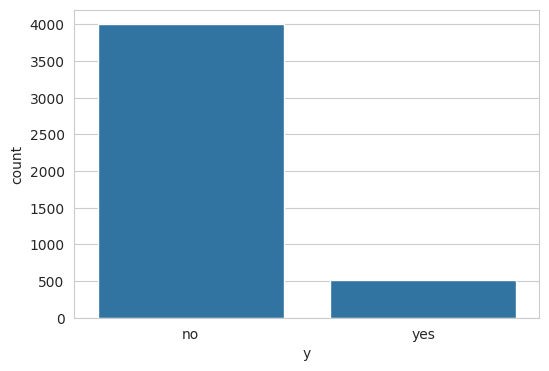

In [10]:
# Используйте sns.countplot() или value_counts().plot(kind='bar')
# ВАШ КОД
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6,4))
sns.countplot(data=bank, x='y')
plt.show()

---

**Вычислите процент клиентов, открывших вклад**

In [11]:
# ВАШ КОД
perc = bank['target'].mean() * 100
print(f"{perc:.2f}%")

11.52%


**Вопрос:** Сбалансированы ли классы? Какой класс преобладает?

**Ответ:** Классы несбалансированы, преобладает "no"

---

### ****3.2. Анализ пропущенных значений****

> 📚 **Подсказка:** Проверка пропусков с помощью `isna().sum()` показана в [**Занятии 1, Часть 3.6**](https://colab.research.google.com/drive/1Cnp7hPUUu5dorlhPPHUeztnnoq5Z2j4W?usp=sharing#scrollTo=1f244634) и [**Занятии 2, Часть 2.2**](https://colab.research.google.com/drive/1aT36P0Jc-dIjYOx6Hh8yecFSgt-z3Fan?usp=sharing#scrollTo=e96e5f15).

**Проверьте наличие пропущенных значений в датасете с помощью `isna().sum()`**

In [12]:
# ВАШ КОД
bank.isna().sum()

,0
age,0
job,38
marital,0
education,187
default,0
balance,0
housing,0
loan,0
contact,1324
day,0


**Вычислите процент пропущенных значений в каждом столбце датасета**

In [13]:
# ВАШ КОД
miss_perc = (bank.isna().sum() / len(bank)) * 100
print(miss_perc[miss_perc > 0].sort_values(ascending=False))

poutcome     81.950896
contact      29.285556
education     4.136253
job           0.840522
dtype: float64


**Постройте столбчатую диаграмму (`barplot`) для визуализации процента пропусков**

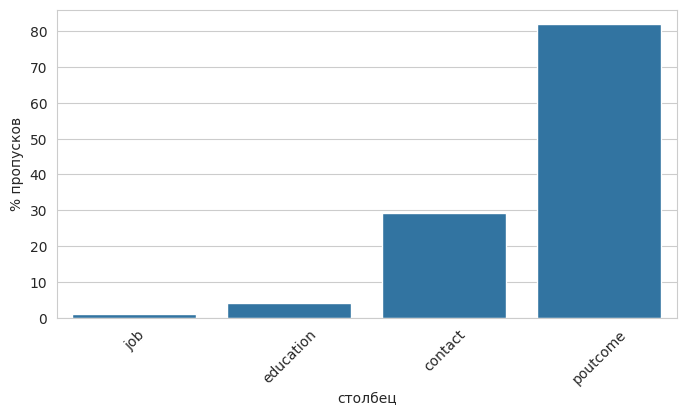

In [14]:
# ВАШ КОД
import matplotlib.pyplot as plt
import seaborn as sns

miss_df = miss_perc[miss_perc > 0].reset_index()
miss_df.columns = ['столбец', '% пропусков']

plt.figure(figsize=(8,4))
sns.barplot(data=miss_df, x='столбец', y='% пропусков')
plt.xticks(rotation=45)
plt.show()

**Вопрос:** В каких столбцах больше всего пропусков? Какой процент данных потеряем, если удалим все строки с пропусками?

**Ответ:** Больше всего пропусков в столбце poutcome, затем contact, education. При удалении потеряем около 85% данных.

---

### ****3.3. Анализ числовых признаков****

> 📚 **Подсказка:** Построение гистограмм с разбивкой по целевой переменной (`hue`) показано в [**Занятии 2, Часть 2.4**](https://colab.research.google.com/drive/1aT36P0Jc-dIjYOx6Hh8yecFSgt-z3Fan?usp=sharing#scrollTo=ea28aa58).

**Обязательно постройте гистограммы для следующих признаков:**
- `age` — возраст
- `balance` — баланс на счёте  
- `duration` — длительность звонка

**Постройте гистограммы для числовых признаков с разбивкой по целевой переменной**

> Используйте `sns.histplot()` с параметром `hue='target'`

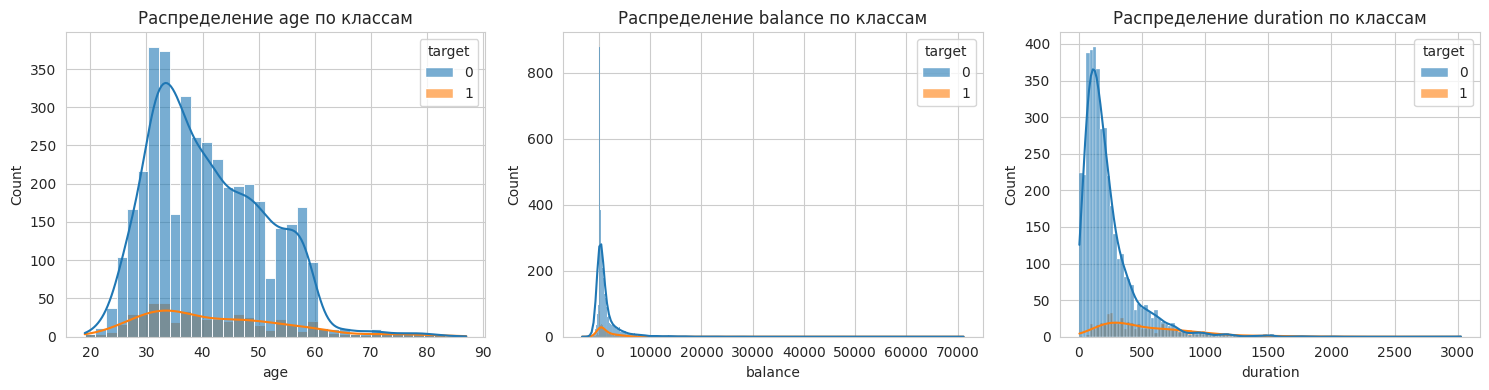

In [15]:
numeric_features = ['age', 'balance', 'duration']

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for i, col in enumerate(numeric_features):
    sns.histplot(data=bank, x=col, hue='target', kde=True, ax=axes[i], alpha=0.6)
    axes[i].set_title(f'Распределение {col} по классам')

plt.tight_layout()
plt.show()

*(При желании, можете не использовать мои шаблоны, а написать код для построения графиков с нуля и самостоятельно)*

**Вопрос:** Какие наблюдения вы можете сделать? Какие признаки различаются для клиентов, открывших и не открывших вклад?

**Ответ:** Клиенты, открывшие вклад, чуть старше. У открывших вклад баланс в среднем выше. Длительность звонка у согласившихся значительно выше

---

### ****Задание 3.4. Анализ категориальных признаков****

> 📚 **Подсказка:** Построение столбчатой диаграммы (`barplot`) для анализа связи категориальных признаков с целевой переменной показано в [**Занятии 2, Часть 2.5**](https://colab.research.google.com/drive/1aT36P0Jc-dIjYOx6Hh8yecFSgt-z3Fan?usp=sharing#scrollTo=ea6a781f).

**Постройте графики для анализа доли открывших депозит по категориальным признакам ('job', 'marital', 'education', 'contact'):**

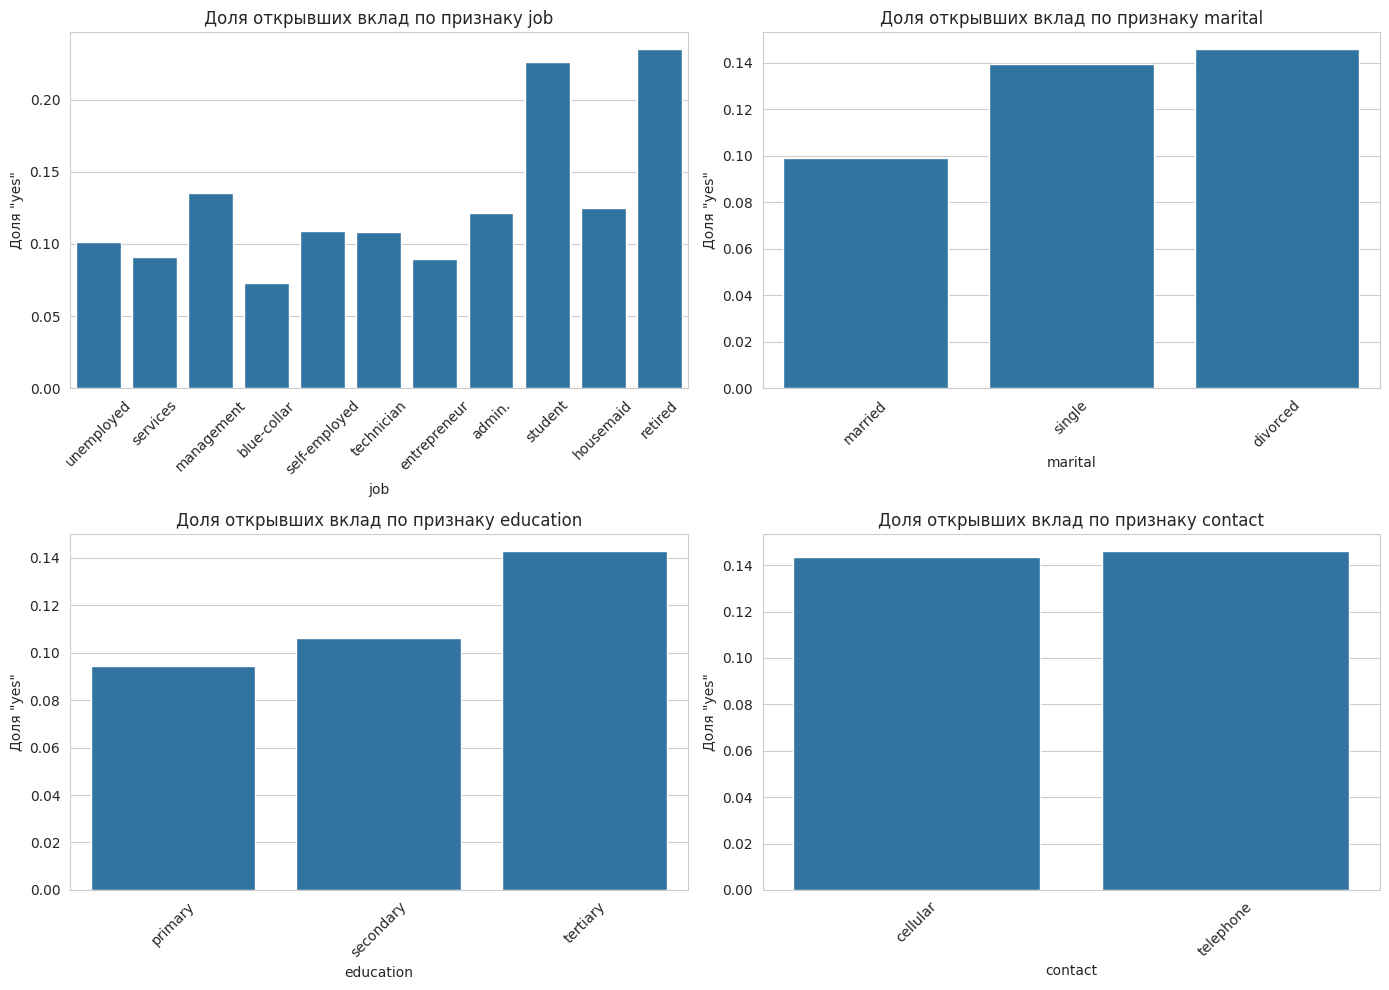

In [16]:
cat_features = ['job', 'marital', 'education', 'contact']

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, col in enumerate(cat_features):
    sns.barplot(data=bank, x=col, y='target', ax=axes[i], errorbar=None)
    axes[i].set_title(f'Доля открывших вклад по признаку {col}')
    axes[i].set_ylabel('Доля "yes"')
    axes[i].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

---

**Ответьте на вопросы:**

**Вопрос:** Люди каких профессий чаще открывают депозит?

**Ответ:** В основном пенсионеры и студенты

**Вопрос:** Влияет ли семейное положение на вероятность открытия депозита?

**Ответ:** Да, но не сильно. Одинокие и разведённые чуть чаще открывают вклады

**Вопрос:** Какой тип связи (contact) наиболее эффективен?

**Ответ:** Телефон

**Вопрос:** Какие в общем категории клиентов чаще открывают вклад (примерный портрет по всем категориальным признакам в совокупности)?

**Ответ:** Разведённые пенсионеры с высшим образованием, с которыми связались по телефону

---

### ****Задание 3.5. Анализ связей между признаками (Boxplot)****

> 📚 **Подсказка:** Использование boxplot для анализа распределений показано в [**Занятии 2, Часть 2.6**](https://colab.research.google.com/drive/1aT36P0Jc-dIjYOx6Hh8yecFSgt-z3Fan?usp=sharing#scrollTo=592b07cc).

**Постройте `boxplot` для анализа баланса по уровню образования**

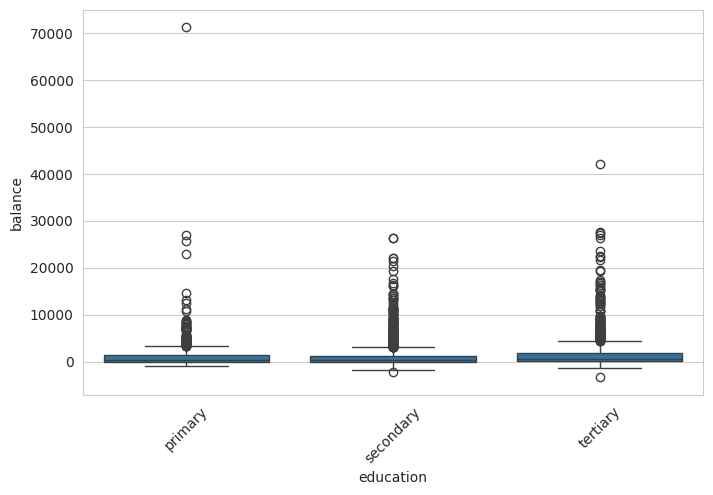

In [17]:
# ВАШ КОД
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,5))
sns.boxplot(data=bank, x='education', y='balance')
plt.xticks(rotation=45)
plt.show()

**Вопрос:** Различается ли баланс у клиентов с разным образованием?

**Ответ:** Да, различается. У клиентов с высшим образованием баланс в среднем выше и разброс больше. У клиентов с начальным образованием баланс ниже и больше выбросов в отрицательную сторону. Среднее образование занимает промежуточное положение

---

### ****Задание 3.6. Группировка данных****

> 📚 **Подсказка:** Метод `groupby()` подробно разобран в [**Занятии 1, Часть 3.7**](https://colab.research.google.com/drive/1Cnp7hPUUu5dorlhPPHUeztnnoq5Z2j4W?usp=sharing#scrollTo=baa512e4).

**Вычислите средний баланс и долю открывших депозит по типу работы**

In [18]:
# ВАШ КОД
group_job = bank.groupby('job').agg(avg_balance=('balance', 'mean'), success_rate=('target', 'mean')).round(3)
print(group_job.sort_values('success_rate', ascending=False))

               avg_balance  success_rate
job                                     
retired           2319.191         0.235
student           1543.821         0.226
management        1766.929         0.135
housemaid         2083.804         0.125
admin.            1226.736         0.121
self-employed     1392.410         0.109
technician        1330.996         0.108
unemployed        1089.422         0.102
services          1103.957         0.091
entrepreneur      1645.125         0.089
blue-collar       1085.162         0.073


**Вычислите долю открывших депозит по уровню образования**

In [19]:
# ВАШ КОД
group_edu = bank.groupby('education')['target'].mean().round(3).sort_values(ascending=False)
print(group_edu)

education
tertiary     0.143
secondary    0.106
primary      0.094
Name: target, dtype: float64


---

## ****Часть 4. Формулировка гипотез и план экспериментов****

> 📚 **Подсказка:** Формулировка гипотез на основе EDA описана в [**Занятии 2, Часть 3**](https://colab.research.google.com/drive/1aT36P0Jc-dIjYOx6Hh8yecFSgt-z3Fan?usp=sharing#scrollTo=329f49e7).

На основе проведённого EDA сформулируйте **минимум 3 гипотезы** о том, какие признаки и преобразования могут улучшить модель.

### ****Ваши гипотезы:****

(Дважды нажмите правой кнопкой мыши на ячейку ниже, чтобы вписать свои гипотезы)

| № | Наблюдение из EDA | Гипотеза | Как проверить | Метрика для сравнения |
|---|-------------------|----------|---------------|----------------------|
| 1 | duration сильно различается | Проверим, стоит ли оставлять | Обучить модель с duration и без него | F1-score, ROC-AUC |
| 2 | Многие клиенты не контактировали (pdays) | Создать бинарный признак was_contacted | Добавить новый признак, обучить модель, сравнить с базовой | F1-score, Accuracy |
| 3 | В столбце balance много нулей и отрицательных значений | Создать бинарный признак has_positive_balance | Добавить признак | F1-score, ROC-AUC |

**Примеры формулировок (для ориентира):**

| Наблюдение | Гипотеза | Как проверить | Метрика |
|------------|----------|---------------|---------|
| `duration` сильно различается у классов | Признак важен для предсказания | Сравнить accuracy с `duration` и без него | Accuracy, F1 |
| `pdays` = -1 означает "не контактировали" | Создать бинарный признак `was_contacted` | Добавить признак, сравнить accuracy | Accuracy, F1 |
| `balance` имеет отрицательные значения | Создать признак `has_positive_balance` | Добавить признак, сравнить accuracy | Accuracy, F1 |
| В `job` есть пропуски | Факт пропуска может быть информативен | Создать `job_unknown`, сравнить accuracy | Accuracy, F1 |
| Много категориальных признаков | One-Hot Encoding улучшит модель | `pd.get_dummies()`, сравнить accuracy | Accuracy, F1 |

> 📚 **Подсказка:** Методология проверки гипотез через эксперименты подробно разобрана в [**Занятии 2, Часть 6**](https://colab.research.google.com/drive/1aT36P0Jc-dIjYOx6Hh8yecFSgt-z3Fan?usp=sharing#scrollTo=28a74583).

---

## ****Часть 5. Сравнение методов классификации****

> 📚 **Подсказка:** Различные методы классификации (логистическая регрессия, деревья решений, ансамбли, SVM, KNN) подробно разбирались на занятиях по supervised learning.

### ****5.1. Расширенная функция оценки модели****

> 📚 **Подсказка:** Базовая функция `evaluate_model()` была создана в [**Занятии 2, после Части 4.6**](https://colab.research.google.com/drive/1aT36P0Jc-dIjYOx6Hh8yecFSgt-z3Fan?usp=sharing#scrollTo=maxKagcsxhv8).

In [20]:
def evaluate_model_advanced(model, X, y, model_name="Model"):
    """
    Расширенная оценка модели с множественными метриками.

    Параметры:
    ----------
    model : sklearn estimator
        Модель для обучения и оценки
    X : DataFrame или array
        Признаки
    y : Series или array
        Целевая переменная
    model_name : str
        Название модели для отображения

    Возвращает:
    -----------
    dict : словарь с метриками
    """
    # 1. Разделение данных (80% train, 20% test)
    X_train, X_test, y_train, y_test = train_test_split(
        X, y,
        test_size=0.2,
        random_state=42,
        stratify=y
    )

    # 2. Масштабирование (ВАЖНО: fit только на train!)
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    # 3. Обучение модели
    model.fit(X_train_scaled, y_train)

    # 4. Предсказание
    y_pred = model.predict(X_test_scaled)

    # 5. Вероятности (если модель поддерживает)
    if hasattr(model, 'predict_proba'):
        y_proba = model.predict_proba(X_test_scaled)[:, 1]
        roc_auc = roc_auc_score(y_test, y_proba)
    else:
        y_proba = None
        roc_auc = None

    # 6. Расчёт метрик
    results = {
        'model_name': model_name,
        'accuracy': accuracy_score(y_test, y_pred),
        'precision': precision_score(y_test, y_pred),
        'recall': recall_score(y_test, y_pred),
        'f1': f1_score(y_test, y_pred),
        'roc_auc': roc_auc
    }

    return results, y_test, y_pred, y_proba

### ****5.2. Простая функция оценки (для быстрых экспериментов)****

In [21]:
def evaluate_model(X, y):
    """
    Быстрая оценка модели логистической регрессии.
    Возвращает только accuracy.
    """
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y
    )

    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    model = LogisticRegression(random_state=42, max_iter=1000)
    model.fit(X_train_scaled, y_train)

    y_pred = model.predict(X_test_scaled)
    accuracy = accuracy_score(y_test, y_pred)

    return accuracy

### ****5.3. Подготовка данных для baseline****

In [22]:
# Выбираем только числовые признаки для baseline
numeric_cols = ['age', 'balance', 'day', 'duration', 'campaign', 'pdays', 'previous']

# Подготовьте X и y
X_baseline = bank[numeric_cols]
y_baseline = bank['target']

print(f"Размер X: {X_baseline.shape}")
print(f"Размер y: {y_baseline.shape}")

Размер X: (4521, 7)
Размер y: (4521,)


### ****5.4. Задание: Сравните ВСЕ методы классификации****

**Создайте словарь со всеми моделями:**

In [23]:
# Словарь моделей для сравнения
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
    'Gradient Boosting': GradientBoostingClassifier(random_state=42),
    'AdaBoost': AdaBoostClassifier(random_state=42, algorithm='SAMME'),
    'SVM': SVC(probability=True, random_state=42),
    'KNN': KNeighborsClassifier(),
    'Naive Bayes': GaussianNB()
}

**Обучите все модели и соберите результаты:**

In [24]:
# Словарь для хранения всех результатов экспериментов
all_results = {}

# Список для сбора результатов сравнения моделей
comparison_results = []

print("=" * 70)
print("СРАВНЕНИЕ ВСЕХ МЕТОДОВ КЛАССИФИКАЦИИ (BASELINE)")
print("=" * 70)

for name, model in models.items():
    results, _, _, _ = evaluate_model_advanced(model, X_baseline, y_baseline, name)
    comparison_results.append(results)

    auc = f"{results['roc_auc']:.4f}" if results['roc_auc'] else "N/A"
    print(f"{name:25} | Accuracy: {results['accuracy']:.4f} | F1: {results['f1']:.4f} | ROC-AUC: {auc}")
print("=" * 70)

СРАВНЕНИЕ ВСЕХ МЕТОДОВ КЛАССИФИКАЦИИ (BASELINE)
Logistic Regression       | Accuracy: 0.8862 | F1: 0.2370 | ROC-AUC: 0.8162
Decision Tree             | Accuracy: 0.8475 | F1: 0.3365 | ROC-AUC: 0.6252
Random Forest             | Accuracy: 0.8729 | F1: 0.2857 | ROC-AUC: 0.8449
Gradient Boosting         | Accuracy: 0.8807 | F1: 0.3494 | ROC-AUC: 0.8491
AdaBoost                  | Accuracy: 0.8807 | F1: 0.2800 | ROC-AUC: 0.8366
SVM                       | Accuracy: 0.8873 | F1: 0.1639 | ROC-AUC: 0.7408
KNN                       | Accuracy: 0.8917 | F1: 0.3718 | ROC-AUC: 0.7192
Naive Bayes               | Accuracy: 0.8575 | F1: 0.3768 | ROC-AUC: 0.8009


<details>
<summary><b>Подсказка (код):</b></summary>

</details>

### ****5.5. Создайте DataFrame с результатами и визуализируйте****

            model_name  accuracy  precision  recall      f1  roc_auc
0          Naive Bayes    0.8575     0.3786  0.3750  0.3768   0.8009
1                  KNN    0.8917     0.5577  0.2788  0.3718   0.7192
2    Gradient Boosting    0.8807     0.4677  0.2788  0.3494   0.8491
3        Decision Tree    0.8475     0.3365  0.3365  0.3365   0.6252
4        Random Forest    0.8729     0.4035  0.2212  0.2857   0.8449
5             AdaBoost    0.8807     0.4565  0.2019  0.2800   0.8366
6  Logistic Regression    0.8862     0.5161  0.1538  0.2370   0.8162
7                  SVM    0.8873     0.5556  0.0962  0.1639   0.7408


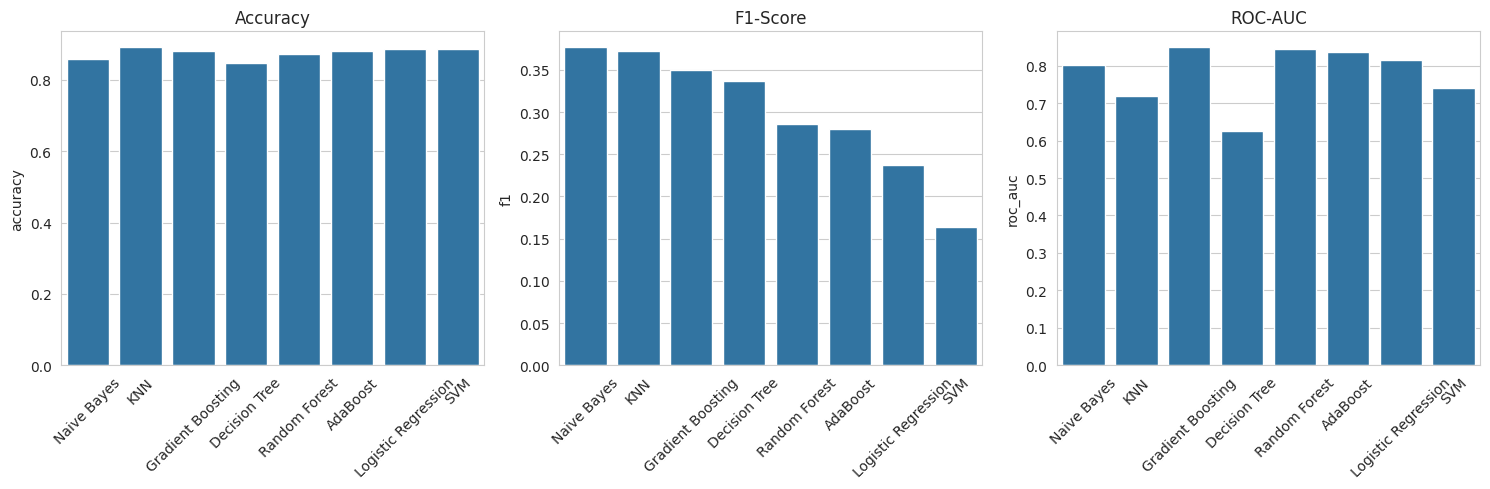

In [25]:
df_comp = pd.DataFrame(comparison_results)
df_comp = df_comp.sort_values('f1', ascending=False).reset_index(drop=True)

print(df_comp.round(4))

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

metrics = ['accuracy', 'f1', 'roc_auc']
titles = ['Accuracy', 'F1-Score', 'ROC-AUC']

for i, (metric, title) in enumerate(zip(metrics, titles)):
    sns.barplot(data=df_comp, x='model_name', y=metric, ax=axes[i])
    axes[i].set_title(title)
    axes[i].set_xlabel('')
    axes[i].tick_params(axis='x', rotation=45)
    axes[i].legend().remove() if axes[i].legend() else None

plt.tight_layout()
plt.show()

### ****5.6. Ответьте на вопросы****

**Вопрос:** Какие 3 модели показали лучший результат по F1-Score?

**Ответ:** Naive Bayes, KNN, Gradient Boosting

**Вопрос:** Почему мы ориентируемся на F1-Score, а не на Accuracy? (Подсказка: вспомните баланс классов)

**Ответ:** Accuracy может быть высокой даже при плохом предсказании редкого класса. F1 учитывает и точность, и полноту

**Вопрос:** Какая модель показала лучший ROC-AUC? Что это означает?

**Ответ:** Gradient Boosting. Это оказывает способность модели разделять классы: чем ближе к 1, тем лучше

---

## ****Часть 6. Стратегии обработки пропусков****

> 📚 **Подсказка:** Стратегии заполнения пропусков (удаление, заполнение модой/медианой, создание признаков) подробно разобраны в [**Занятии 2, Часть 5**](https://colab.research.google.com/drive/1aT36P0Jc-dIjYOx6Hh8yecFSgt-z3Fan?usp=sharing#scrollTo=89cec4d9).

### ****6.1. Стратегия A: Удаление строк с пропусками****

In [26]:
# Посмотрим, сколько данных потеряем
df_dropped = bank.dropna()

print(f"Было строк: {len(bank)}")
print(f"Стало строк: {len(df_dropped)}")
print(f"Потеряно: {len(bank) - len(df_dropped)} ({(len(bank) - len(df_dropped)) / len(bank) * 100:.1f}%)")

Было строк: 4521
Стало строк: 764
Потеряно: 3757 (83.1%)


**Вопрос:** Приемлемо ли терять столько данных?

**Ответ:**  Нет, категорически не приемлемо. Потеря около 80% данных слишком велика. Лучше использовать заполнение пропусков.

---

### ****6.2. Стратегия B: Заполнение модой****

> 📚 **Подсказка:** Заполнение пропусков модой через `fillna()` рассматривалось в [**Занятии 2, Часть 5, Стратегия B**](https://colab.research.google.com/drive/1aT36P0Jc-dIjYOx6Hh8yecFSgt-z3Fan?usp=sharing#scrollTo=8e470458).

**Заполните категориальные пропуски модой (самым частым значением)**

In [38]:
df_filled = bank.copy()

cat_cols_with_na = ['job', 'education', 'contact', 'poutcome']

for col in cat_cols_with_na:
    if df_filled[col].isna().sum() > 0:
        mode_val = df_filled[col].mode()[0]          # находим моду
        df_filled[col] = df_filled[col].fillna(mode_val)

print(f"Пропусков после заполнения: {df_filled.isna().sum().sum()}")

Пропусков после заполнения: 0


### ****6.3. Стратегия C: Создание признаков из пропусков****

> 📚 **Подсказка:** Создание бинарных признаков из пропусков (например, `has_cabin` в Titanic) рассматривалось в [**Занятии 2, Часть 6, Эксперимент 2, Тест D**](https://colab.research.google.com/drive/1aT36P0Jc-dIjYOx6Hh8yecFSgt-z3Fan?usp=sharing#scrollTo=df9d9180).
>
> **Идея:** Сам факт того, что значение неизвестно, может быть информативен! Например: если клиент не указал профессию — это может что-то говорить о нём.

**Создайте признаки "был ли пропуск" ДО заполнения**

In [39]:
df_fe = bank.copy()

df_fe['job_unknown'] = bank['job'].isna().astype(int)
df_fe['edu_unknown'] = bank['education'].isna().astype(int)
df_fe['contact_unknown'] = bank['contact'].isna().astype(int)
df_fe['poutcome_unknown'] = bank['poutcome'].isna().astype(int)

print("Новые признаки:")
print(df_fe[['job_unknown', 'edu_unknown', 'contact_unknown', 'poutcome_unknown']].head())

Новые признаки:
   job_unknown  edu_unknown  contact_unknown  poutcome_unknown
0            0            0                0                 1
1            0            0                0                 0
2            0            0                0                 0
3            0            0                1                 1
4            0            0                1                 1


---

## ****Часть 7. Feature Engineering и отбор признаков****

> 📚 **Подсказка:** Создание новых признаков на основе анализа данных описано в [**Занятии 2, Часть 6**](https://colab.research.google.com/drive/1aT36P0Jc-dIjYOx6Hh8yecFSgt-z3Fan?usp=sharing#scrollTo=28a74583).

### ****7.1. Создание новых признаков****

**Создайте следующие признаки на основе гипотез из EDA:**

In [43]:
df_fe = bank.copy()

df_fe['was_contacted'] = (bank['pdays'] != -1).astype(int)

df_fe['has_positive_balance'] = (bank['balance'] > 0).astype(int)

df_fe['job_unknown'] = bank['job'].isna().astype(int)
df_fe['education_unknown'] = bank['education'].isna().astype(int)
df_fe['contact_unknown'] = bank['contact'].isna().astype(int)

for col in ['job', 'education', 'contact', 'poutcome']:
    if df_fe[col].isna().sum() > 0:
        mode_val = df_fe[col].mode()[0]
        df_fe[col] = df_fe[col].fillna(mode_val)

print("Созданные признаки:")
print(df_fe[['was_contacted', 'has_positive_balance', 'job_unknown', 'education_unknown', 'contact_unknown']].head(10))

Созданные признаки:
   was_contacted  has_positive_balance  job_unknown  education_unknown  \
0              0                     1            0                  0   
1              1                     1            0                  0   
2              1                     1            0                  0   
3              0                     1            0                  0   
4              0                     0            0                  0   
5              1                     1            0                  0   
6              1                     1            0                  0   
7              0                     1            0                  0   
8              0                     1            0                  0   
9              1                     0            0                  0   

   contact_unknown  
0                0  
1                0  
2                0  
3                1  
4                1  
5                0  
6                0

**Добавьте свои признаки на основе ваших гипотез:**

In [44]:
# ВАШ КОД: создайте дополнительные признаки
df_fe['balance_per_age'] = df_fe['balance'] / (df_fe['age'] + 1)

mean_balance = df_fe['balance'].mean()
df_fe['high_balance'] = (df_fe['balance'] > mean_balance).astype(int)

df_fe['contact_intensity'] = df_fe['campaign'] / (df_fe['pdays'] + 1)

print(df_fe[['was_contacted', 'has_positive_balance', 'job_unknown', 'education_unknown', 'contact_unknown', 'high_balance', 'contact_intensity']].head(10))

   was_contacted  has_positive_balance  job_unknown  education_unknown  \
0              0                     1            0                  0   
1              1                     1            0                  0   
2              1                     1            0                  0   
3              0                     1            0                  0   
4              0                     0            0                  0   
5              1                     1            0                  0   
6              1                     1            0                  0   
7              0                     1            0                  0   
8              0                     1            0                  0   
9              1                     0            0                  0   

   contact_unknown  high_balance  contact_intensity  
0                0             1                inf  
1                0             1           0.002941  
2                0     

### ****7.2. Систематический перебор комбинаций признаков****

> **Цель:** Определить, какие признаки улучшают модель, а какие вносят шум.

**Определите базовый набор признаков и признаки для тестирования:**

In [46]:
# Базовые числовые признаки
base_features = ['age', 'balance', 'duration', 'campaign', 'pdays', 'previous', 'day']

# Новые созданные признаки
new_features = ['was_contacted', 'has_positive_balance', 'job_unknown', 'education_unknown', 'contact_unknown', 'high_balance']

y = df_fe['target']

X_base = df_fe[base_features]
acc_base = evaluate_model(X_base, y)
print(f"Базовая модель ({len(base_features)} признаков): accuracy = {acc_base:.4f}")
print("=" * 60)

print("Добавление по одному признаку:")
for feat in new_features:
    X_test = df_fe[base_features + [feat]]
    acc = evaluate_model(X_test, y)
    change = acc - acc_base
    sign = "+" if change > 0 else ""
    print(f"  + {feat:25} accuracy = {acc:.4f}  (изменение: {sign}{change:.4f})")

print("=" * 60)

Базовая модель (7 признаков): accuracy = 0.8862
Добавление по одному признаку:
  + was_contacted             accuracy = 0.8917  (изменение: +0.0055)
  + has_positive_balance      accuracy = 0.8862  (изменение: 0.0000)
  + job_unknown               accuracy = 0.8862  (изменение: 0.0000)
  + education_unknown         accuracy = 0.8862  (изменение: 0.0000)
  + contact_unknown           accuracy = 0.8818  (изменение: -0.0044)
  + high_balance              accuracy = 0.8862  (изменение: 0.0000)


**Вопрос:** Какие признаки улучшили модель? Какие ухудшили (внесли шум)?

**Ответ:** was_contacted улучшил модель, а contact_unknown внес шум

### ****7.3. Анализ важности признаков с помощью Random Forest****

ВАЖНОСТЬ ПРИЗНАКОВ (Random Forest)
             feature  importance
            duration    0.345797
             balance    0.157009
                 age    0.152865
                 day    0.129568
               pdays    0.071663
            campaign    0.056195
            previous    0.032213
     contact_unknown    0.015632
        high_balance    0.010684
       was_contacted    0.009030
   education_unknown    0.008592
has_positive_balance    0.007813
         job_unknown    0.002939


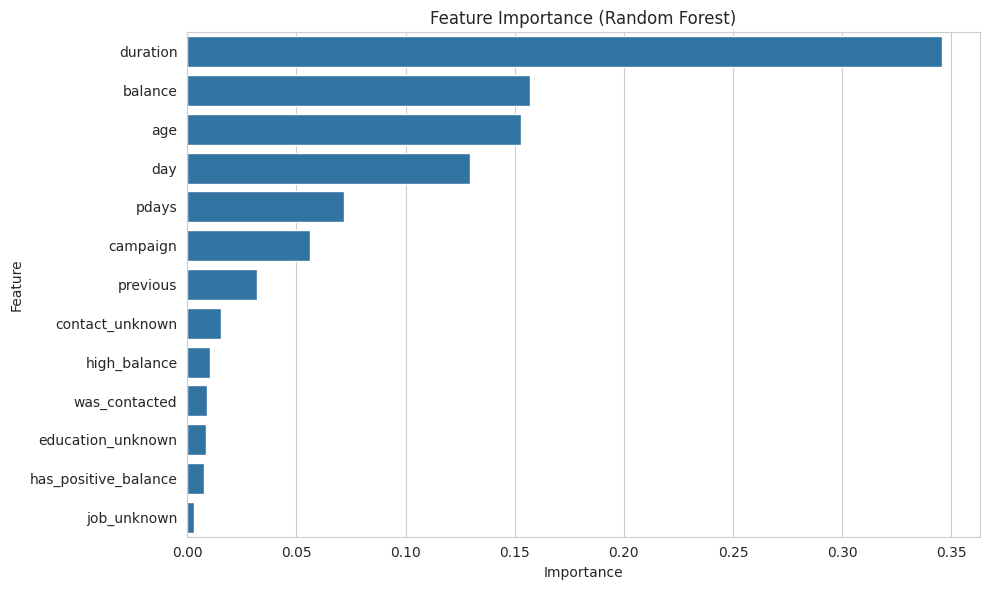

In [47]:
# Соберём все признаки
all_numeric_features = base_features + new_features
X_all = df_fe[all_numeric_features]

# Обучим Random Forest и посмотрим важность признаков
from sklearn.ensemble import RandomForestClassifier

# Масштабирование
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_all)

# Обучение
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_scaled, y)

# Важность признаков
importance_df = pd.DataFrame({
    'feature': all_numeric_features,
    'importance': rf.feature_importances_
}).sort_values('importance', ascending=False)

print("ВАЖНОСТЬ ПРИЗНАКОВ (Random Forest)")
print("=" * 40)
print(importance_df.to_string(index=False))
print("=" * 40)

# Визуализация
plt.figure(figsize=(10, 6))
sns.barplot(data=importance_df, x='importance', y='feature')
plt.title('Feature Importance (Random Forest)')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

### ****7.4. Рекурсивное исключение признаков (RFE)****

> 📚 **Подсказка:** [RFE](https://habr.com/ru/companies/otus/articles/528676/) автоматически отбирает наиболее важные признаки, последовательно удаляя наименее значимые.

In [71]:
from sklearn.feature_selection import RFE

selector = RFE(estimator=LogisticRegression(max_iter=1000, random_state=42), n_features_to_select=7, step=1)
selector.fit(X_scaled, y)

selected_features = [f for f, s in zip(all_numeric_features, selector.support_) if s]
rejected_features = [f for f, s in zip(all_numeric_features, selector.support_) if not s]

print("РЕЗУЛЬТАТЫ RFE")
print("=" * 40)
print(f"Отобранные признаки ({len(selected_features)}): {selected_features}")
print(f"Отвергнутые признаки ({len(rejected_features)}): {rejected_features}")
print("=" * 40)

X_selected = df_fe[selected_features]
accuracy_selected = evaluate_model(X_selected, y)
accuracy_all = evaluate_model(X_all, y)

print(f"\nAccuracy (все {len(all_numeric_features)} признаков): {accuracy_all:.4f}")
print(f"Accuracy (отобранные {len(selected_features)} признаков): {accuracy_selected:.4f}")
print(f"Разница: {accuracy_selected - accuracy_all:+.4f}")

РЕЗУЛЬТАТЫ RFE
Отобранные признаки (7): ['duration', 'campaign', 'pdays', 'was_contacted', 'has_positive_balance', 'contact_unknown', 'high_balance']
Отвергнутые признаки (6): ['age', 'balance', 'previous', 'day', 'job_unknown', 'education_unknown']

Accuracy (все 13 признаков): 0.8851
Accuracy (отобранные 7 признаков): 0.8862
Разница: +0.0011


**Вопрос:** Помог ли отбор признаков улучшить модель? Какие признаки оказались лишними?

**Ответ:** Да, отбор слегка улучшил модель. RFE отверг age, balance, previous, day, job_unknown, education_unknown

---

## ****Часть 8. Кодирование категориальных признаков****

> 📚 **Подсказка:** One-Hot Encoding для категориальных признаков рассматривался в [**Занятии 2, Часть 6**](https://colab.research.google.com/drive/1aT36P0Jc-dIjYOx6Hh8yecFSgt-z3Fan?usp=sharing#scrollTo=28a74583).

### ****8.1. Примените One-Hot Encoding****

In [35]:
# Определяем категориальные столбцы для кодирования
cat_cols_to_encode = ['job', 'marital', 'education', 'default', 'housing',
                       'loan', 'contact', 'month', 'poutcome']

# Применяем One-Hot Encoding
df_encoded = pd.get_dummies(df_fe, columns=cat_cols_to_encode, drop_first=True)

print(f"Было признаков: {df_fe.shape[1]}")
print(f"Стало признаков: {df_encoded.shape[1]}")

Было признаков: 23
Стало признаков: 45


### ****8.2. Подготовьте финальный набор признаков****

In [36]:
# Удаляем целевые переменные и служебные столбцы
cols_to_drop = ['y', 'target']
X_final = df_encoded.drop(columns=cols_to_drop)
y_final = df_encoded['target']

print(f"Финальный размер X: {X_final.shape}")
print(f"Количество признаков: {X_final.shape[1]}")

Финальный размер X: (4521, 43)
Количество признаков: 43


### ****8.3. Сравните модели на расширенном наборе признаков****

In [57]:
print("=" * 70)
print("СРАВНЕНИЕ МОДЕЛЕЙ НА РАСШИРЕННОМ НАБОРЕ ПРИЗНАКОВ")
print("=" * 70)

comparison_results_extended = []

for name, model in models.items():
    results, _, _, _ = evaluate_model_advanced(model, X_final, y_final, name)
    comparison_results_extended.append(results)
    auc = f"{results['roc_auc']:.4f}" if results['roc_auc'] else "N/A"
    print(f"{name:25} | Accuracy: {results['accuracy']:.4f} | F1: {results['f1']:.4f} | ROC-AUC: {auc}")

print("=" * 70)

df_comparison_extended = pd.DataFrame(comparison_results_extended)
df_comparison_extended = df_comparison_extended.sort_values('f1', ascending=False).reset_index(drop=True)

print("\nРАНЖИРОВАНИЕ ПО F1-SCORE:")
print(df_comparison_extended[['model_name', 'accuracy', 'f1', 'roc_auc']].round(4).to_string(index=False))

СРАВНЕНИЕ МОДЕЛЕЙ НА РАСШИРЕННОМ НАБОРЕ ПРИЗНАКОВ
Logistic Regression       | Accuracy: 0.8917 | F1: 0.3951 | ROC-AUC: 0.8918
Decision Tree             | Accuracy: 0.8497 | F1: 0.4188 | ROC-AUC: 0.6850
Random Forest             | Accuracy: 0.8851 | F1: 0.3158 | ROC-AUC: 0.8975
Gradient Boosting         | Accuracy: 0.8895 | F1: 0.4382 | ROC-AUC: 0.8991
AdaBoost                  | Accuracy: 0.8906 | F1: 0.3774 | ROC-AUC: 0.8770
SVM                       | Accuracy: 0.8840 | F1: 0.2857 | ROC-AUC: 0.8764
KNN                       | Accuracy: 0.8873 | F1: 0.3108 | ROC-AUC: 0.7500
Naive Bayes               | Accuracy: 0.8254 | F1: 0.3577 | ROC-AUC: 0.7920

РАНЖИРОВАНИЕ ПО F1-SCORE:
         model_name  accuracy     f1  roc_auc
  Gradient Boosting    0.8895 0.4382   0.8991
      Decision Tree    0.8497 0.4188   0.6850
Logistic Regression    0.8917 0.3951   0.8918
           AdaBoost    0.8906 0.3774   0.8770
        Naive Bayes    0.8254 0.3577   0.7920
      Random Forest    0.8851 0.3158   

---

## ****Часть 9. Выбор топ-3 моделей****

### ****9.1. Определите топ-3 модели по F1-Score****

In [58]:
# Выберите топ-3 модели из df_comparison_extended
top_3_models = df_comparison_extended.head(3)['model_name'].tolist()

print("ТОП-3 МОДЕЛИ ПО F1-SCORE:")
print("=" * 40)
for i, name in enumerate(top_3_models, 1):
    row = df_comparison_extended[df_comparison_extended['model_name'] == name].iloc[0]
    print(f"{i}. {name}: F1 = {row['f1']:.4f}, ROC-AUC = {row['roc_auc']:.4f}")
print("=" * 40)

ТОП-3 МОДЕЛИ ПО F1-SCORE:
1. Gradient Boosting: F1 = 0.4382, ROC-AUC = 0.8991
2. Decision Tree: F1 = 0.4188, ROC-AUC = 0.6850
3. Logistic Regression: F1 = 0.3951, ROC-AUC = 0.8918


### ****9.2. Постройте ROC-кривые для топ-3 моделей****

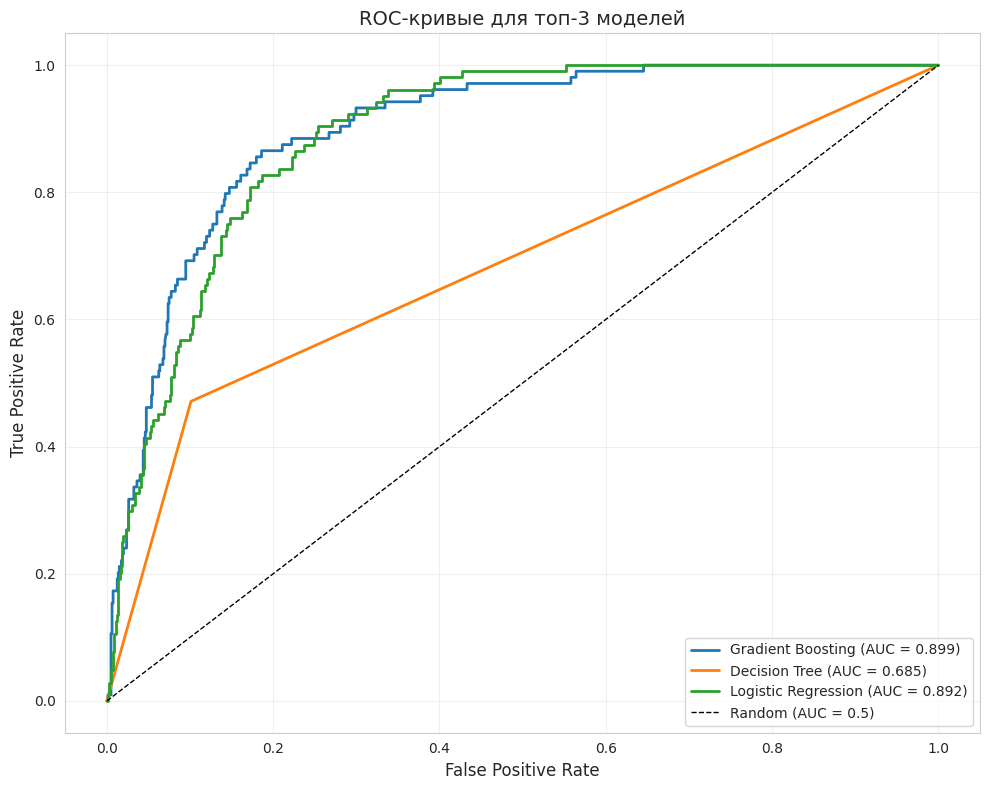

In [59]:
from sklearn.metrics import roc_curve, auc

# Подготовка данных
X_train, X_test, y_train, y_test = train_test_split(
    X_final, y_final, test_size=0.2, random_state=42, stratify=y_final
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Словарь для топ-3 моделей
top_3_model_objects = {}
for name in top_3_models:
    if name == 'Logistic Regression':
        top_3_model_objects[name] = LogisticRegression(max_iter=1000, random_state=42)
    elif name == 'Random Forest':
        top_3_model_objects[name] = RandomForestClassifier(n_estimators=100, random_state=42)
    elif name == 'Gradient Boosting':
        top_3_model_objects[name] = GradientBoostingClassifier(random_state=42)
    elif name == 'AdaBoost':
        top_3_model_objects[name] = AdaBoostClassifier(random_state=42, algorithm='SAMME')
    elif name == 'Decision Tree':
        top_3_model_objects[name] = DecisionTreeClassifier(random_state=42)
    elif name == 'SVM':
        top_3_model_objects[name] = SVC(probability=True, random_state=42)
    elif name == 'KNN':
        top_3_model_objects[name] = KNeighborsClassifier()
    elif name == 'Naive Bayes':
        top_3_model_objects[name] = GaussianNB()

# Построение ROC-кривых
plt.figure(figsize=(10, 8))

for name, model in top_3_model_objects.items():
    model.fit(X_train_scaled, y_train)

    if hasattr(model, 'predict_proba'):
        y_proba = model.predict_proba(X_test_scaled)[:, 1]
    else:
        y_proba = model.decision_function(X_test_scaled)

    fpr, tpr, _ = roc_curve(y_test, y_proba)
    roc_auc = auc(fpr, tpr)

    plt.plot(fpr, tpr, linewidth=2, label=f'{name} (AUC = {roc_auc:.3f})')

plt.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random (AUC = 0.5)')
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('ROC-кривые для топ-3 моделей', fontsize=14)
plt.legend(loc='lower right', fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### ****9.3. Постройте Confusion Matrix для топ-3 моделей****

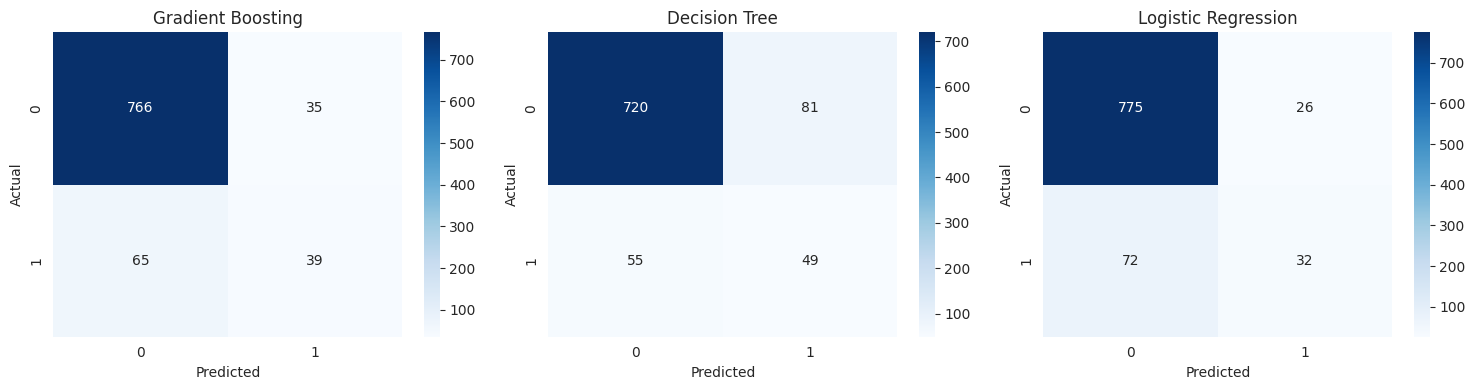

In [60]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for i, (name, model) in enumerate(top_3_model_objects.items()):
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)

    cm = confusion_matrix(y_test, y_pred)

    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[i])
    axes[i].set_title(f'{name}')
    axes[i].set_xlabel('Predicted')
    axes[i].set_ylabel('Actual')

plt.tight_layout()
plt.show()

**Вопрос:** Какая модель лучше всего находит положительный класс (клиентов, которые откроют вклад)?

**Ответ:** : Лучше всего положительный класс находит Gradient Boosting

---

## ****Часть 10. Оптимизация гиперпараметров с GridSearchCV****

> 📚 **Подсказка:** GridSearchCV перебирает все комбинации гиперпараметров и выбирает лучшую с помощью кросс-валидации.

### ****10.1. Определите сетки гиперпараметров для топ-3 моделей****

In [62]:
param_grids = {}

if 'Logistic Regression' in top_3_models:
    param_grids['Logistic Regression'] = {'C': [0.1, 1, 10], 'solver': ['liblinear', 'lbfgs'], 'max_iter': [1000]}

if 'Random Forest' in top_3_models:
    param_grids['Random Forest'] = {'n_estimators': [50, 100, 150], 'max_depth': [10, 20, None], 'min_samples_split': [2, 5], 'min_samples_leaf': [1, 2]}

if 'Gradient Boosting' in top_3_models:
    param_grids['Gradient Boosting'] = { 'n_estimators': [50, 100], 'learning_rate': [0.05, 0.1, 0.2], 'max_depth': [3, 5], 'subsample': [0.8, 1.0]}

if 'SVM' in top_3_models:
    param_grids['SVM'] = {'C': [0.1, 1, 10], 'gamma': ['scale', 'auto'], 'kernel': ['rbf']}

if 'KNN' in top_3_models:
    param_grids['KNN'] = {'n_neighbors': [3, 5, 7, 9], 'weights': ['uniform', 'distance']}

if 'Decision Tree' in top_3_models:
    param_grids['Decision Tree'] = {'max_depth': [5, 10, None], 'min_samples_split': [2, 5, 10], 'criterion': ['gini', 'entropy']}

print("Сетки гиперпараметров:")
for name in top_3_models:
    if name in param_grids:
        print(f"{name}: {param_grids[name]}")
    else:
        print(f"{name}: увы, будет использована базовая модель")

Сетки гиперпараметров:
Gradient Boosting: {'n_estimators': [50, 100], 'learning_rate': [0.05, 0.1, 0.2], 'max_depth': [3, 5], 'subsample': [0.8, 1.0]}
Decision Tree: {'max_depth': [5, 10, None], 'min_samples_split': [2, 5, 10], 'criterion': ['gini', 'entropy']}
Logistic Regression: {'C': [0.1, 1, 10], 'solver': ['liblinear', 'lbfgs'], 'max_iter': [1000]}


### ****10.2. Запустите GridSearchCV для каждой модели из топ-3****

In [63]:
from sklearn.model_selection import GridSearchCV

X_tr, X_te, y_tr, y_te = train_test_split(X_final, y_final, test_size=0.2, random_state=42, stratify=y_final)
scaler = StandardScaler()
X_tr_scaled = scaler.fit_transform(X_tr)
X_te_scaled = scaler.transform(X_te)
tuning_results = {}

print("=" * 70)
print("ОПТИМИЗАЦИЯ ГИПЕРПАРАМЕТРОВ (GridSearchCV)")
print("=" * 70)

for name in top_3_models:
    if name not in models:
        print(f"Модель {name} не найдена в словаре models. Увы.")
        continue

    base_model = models[name]
    param_grid = param_grids.get(name, {})

    if not param_grid:
        print(f"\n{name}: увы. Используем базовую модель.")
        base_model.fit(X_tr_scaled, y_tr)
        y_pred = base_model.predict(X_te_scaled)
        if hasattr(base_model, 'predict_proba'):
            y_proba = base_model.predict_proba(X_te_scaled)[:, 1]
            roc = roc_auc_score(y_te, y_proba)
        else:
            roc = None
        tuning_results[name] = {'test_accuracy': accuracy_score(y_te, y_pred), 'test_f1': f1_score(y_te, y_pred), 'test_roc_auc': roc, 'best_params': 'базовая модель'}
        continue

    grid = GridSearchCV(base_model, param_grid, cv=5, scoring='f1', n_jobs=-1, verbose=1)
    grid.fit(X_tr_scaled, y_tr)

    best_model = grid.best_estimator_
    y_pred = best_model.predict(X_te_scaled)
    if hasattr(best_model, 'predict_proba'):
        y_proba = best_model.predict_proba(X_te_scaled)[:, 1]
        roc = roc_auc_score(y_te, y_proba)
    else:
        roc = None

    tuning_results[name] = {'test_accuracy': accuracy_score(y_te, y_pred), 'test_f1': f1_score(y_te, y_pred), 'test_roc_auc': roc, 'best_params': grid.best_params_}

    print(f"\n{name}:")
    print(f"  Лучшие параметры: {grid.best_params_}")
    print(f"  Лучшее F1 (CV): {grid.best_score_:.4f}")
    print(f"  Тестовый F1: {tuning_results[name]['test_f1']:.4f}")

print("=" * 70)

ОПТИМИЗАЦИЯ ГИПЕРПАРАМЕТРОВ (GridSearchCV)
Fitting 5 folds for each of 24 candidates, totalling 120 fits

Gradient Boosting:
  Лучшие параметры: {'learning_rate': 0.2, 'max_depth': 3, 'n_estimators': 100, 'subsample': 1.0}
  Лучшее F1 (CV): 0.5219
  Тестовый F1: 0.4505
Fitting 5 folds for each of 18 candidates, totalling 90 fits

Decision Tree:
  Лучшие параметры: {'criterion': 'gini', 'max_depth': None, 'min_samples_split': 10}
  Лучшее F1 (CV): 0.4432
  Тестовый F1: 0.4319
Fitting 5 folds for each of 6 candidates, totalling 30 fits

Logistic Regression:
  Лучшие параметры: {'C': 0.1, 'max_iter': 1000, 'solver': 'liblinear'}
  Лучшее F1 (CV): 0.4612
  Тестовый F1: 0.4051


### ****10.3. Сравните результаты ДО и ПОСЛЕ тюнинга****

In [64]:
print("=" * 70)
print("СРАВНЕНИЕ РЕЗУЛЬТАТОВ ДО И ПОСЛЕ ТЮНИНГА")
print("=" * 70)

comparison_tuning = []

for name in top_3_models:
    # Результаты до тюнинга
    before = df_comparison_extended[df_comparison_extended['model_name'] == name].iloc[0]

    # Результаты после тюнинга
    after = tuning_results.get(name, {})

    if after:
        comparison_tuning.append({
            'Model': name,
            'F1 (до)': before['f1'],
            'F1 (после)': after['test_f1'],
            'Δ F1': after['test_f1'] - before['f1'],
            'Accuracy (до)': before['accuracy'],
            'Accuracy (после)': after['test_accuracy'],
            'Δ Accuracy': after['test_accuracy'] - before['accuracy']
        })

df_tuning_comparison = pd.DataFrame(comparison_tuning)
print(df_tuning_comparison.to_string(index=False))
print("=" * 70)

СРАВНЕНИЕ РЕЗУЛЬТАТОВ ДО И ПОСЛЕ ТЮНИНГА
              Model  F1 (до)  F1 (после)     Δ F1  Accuracy (до)  Accuracy (после)  Δ Accuracy
  Gradient Boosting 0.438202    0.450549 0.012347       0.889503          0.889503    0.000000
      Decision Tree 0.418803    0.431925 0.013121       0.849724          0.866298    0.016575
Logistic Regression 0.395062    0.405063 0.010002       0.891713          0.896133    0.004420


**Вопрос:** Для какой модели тюнинг дал наибольшее улучшение?

**Ответ:** Decision Tree

**Вопрос:** Какие гиперпараметры оказали наибольшее влияние на качество?

**Ответ:** 'criterion', 'max_depth', 'min_samples_split'

---

## ****Часть 11. Финальное сравнение и выводы****

### ****11.1. Постройте итоговую таблицу всех экспериментов****

In [68]:
final_summary = []

baseline_exists = False
if 'df_comp' in dir() and len(df_comp) > 0:
    best_baseline = df_comp.iloc[0]
    baseline_exists = True
elif 'comparison_results' in dir() and len(comparison_results) > 0:
    df_temp = pd.DataFrame(comparison_results).sort_values('f1', ascending=False)
    best_baseline = df_temp.iloc[0]
    baseline_exists = True
else:
    print("Не найдены результаты baseline (df_comp или comparison_results). Пропускаем baseline.")

if baseline_exists:
    n_num = len(numeric_cols) if 'numeric_cols' in dir() else 7
    final_summary.append({'Эксперимент': 'Baseline (числовые признаки)', 'Модель': best_baseline['model_name'], 'Кол-во признаков': n_num, 'F1-Score': best_baseline['f1'], 'Accuracy': best_baseline['accuracy']})

if 'df_comparison_extended' in dir() and len(df_comparison_extended) > 0:
    best_ext = df_comparison_extended.iloc[0]
    n_feat = X_final.shape[1] if 'X_final' in dir() else '?'
    final_summary.append({'Эксперимент': 'Feature Engineering + One-Hot', 'Модель': best_ext['model_name'], 'Кол-во признаков': n_feat, 'F1-Score': best_ext['f1'], 'Accuracy': best_ext['accuracy']})
else:
    print("Не найден df_comparison_extended. Сначала выполните часть 8.3.")

if 'tuning_results' in dir() and len(tuning_results) > 0:
    best_name = max(tuning_results.items(), key=lambda x: x[1]['test_f1'] if x[1]['test_f1'] is not None else 0)
    best_tuned = best_name[1]
    n_feat = X_final.shape[1] if 'X_final' in dir() else '?'
    final_summary.append({'Эксперимент': 'После GridSearchCV', 'Модель': f"{best_name[0]} (tuned)", 'Кол-во признаков': n_feat, 'F1-Score': best_tuned['test_f1'], 'Accuracy': best_tuned['test_accuracy']})
else:
    print("Не найдены tuning_results. Сначала выполните часть 10.2.")

if final_summary:
    df_final = pd.DataFrame(final_summary)
    print("=" * 80)
    print("ИТОГОВАЯ ТАБЛИЦА ЭКСПЕРИМЕНТОВ")
    print("=" * 80)
    print(df_final.round(4).to_string(index=False))
    print("=" * 80)
else:
    print("Нет данных для построения итоговой таблицы.")

ИТОГОВАЯ ТАБЛИЦА ЭКСПЕРИМЕНТОВ
                  Эксперимент                    Модель  Кол-во признаков  F1-Score  Accuracy
 Baseline (числовые признаки)               Naive Bayes                 7    0.3768    0.8575
Feature Engineering + One-Hot         Gradient Boosting                43    0.4382    0.8895
           После GridSearchCV Gradient Boosting (tuned)                43    0.4505    0.8895


### ****11.2. Визуализируйте прогресс улучшения модели****

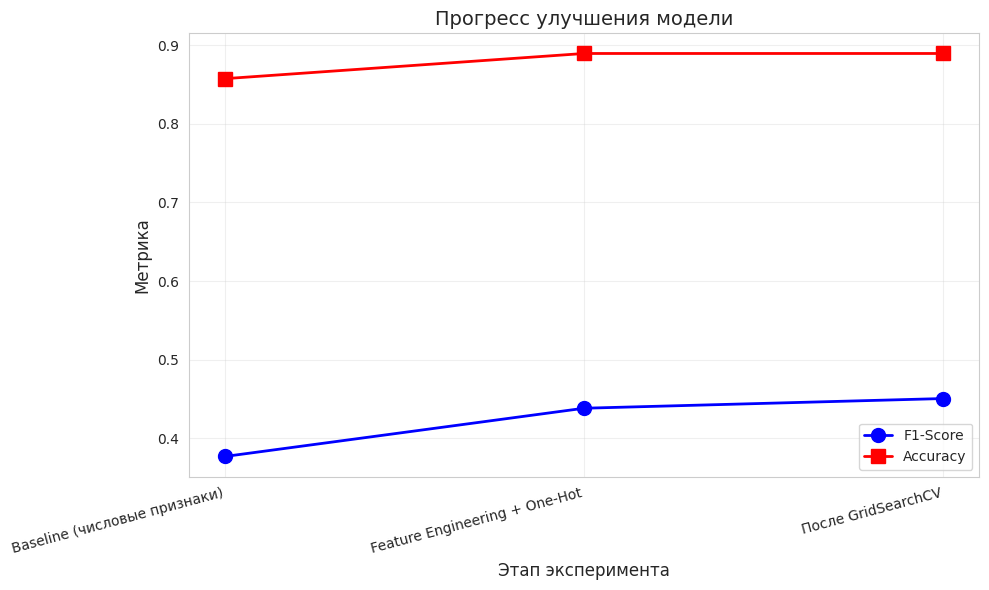

Повышение метрик:
F1-Score: 0.3768 → 0.4505  (прирост: +0.0737)
Accuracy: 0.8575 → 0.8895  (прирост: +0.0320)


In [70]:
# График прогресса
if 'df_final' in dir() and len(df_final) >= 2:
    plt.figure(figsize=(10, 6))
    x = range(len(df_final))
    plt.plot(x, df_final['F1-Score'], 'bo-', markersize=10, linewidth=2, label='F1-Score')
    plt.plot(x, df_final['Accuracy'], 'rs-', markersize=10, linewidth=2, label='Accuracy')
    plt.xticks(x, df_final['Эксперимент'], rotation=15, ha='right')
    plt.xlabel('Этап эксперимента', fontsize=12)
    plt.ylabel('Метрика', fontsize=12)
    plt.title('Прогресс улучшения модели', fontsize=14)
    plt.legend(fontsize=10)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

    # Вычисление прироста (последний - первый)
    f1_start = df_final.iloc[0]['F1-Score']
    f1_end = df_final.iloc[-1]['F1-Score']
    acc_start = df_final.iloc[0]['Accuracy']
    acc_end = df_final.iloc[-1]['Accuracy']

    print(f"Повышение метрик:")
    print(f"F1-Score: {f1_start:.4f} → {f1_end:.4f}  (прирост: {f1_end - f1_start:+.4f})")
    print(f"Accuracy: {acc_start:.4f} → {acc_end:.4f}  (прирост: {acc_end - acc_start:+.4f})")
else:
    print("Недостаточно данных для построения графика.")

### ****11.3. Ответьте на итоговые вопросы****

---

**Вопрос 1:** Какая модель показала лучший финальный результат и почему, по вашему мнению?

**Ответ:** Лучший результат показала Gradient Boosting после настройки гиперпараметров. Эта модель ансамблевая, хорошо работает с табличными данными и умеет выявлять сложные нелинейные зависимости, а также устойчива к несбалансированным классам.

---

**Вопрос 2:** Какие признаки оказались шумовыми (ухудшали модель)?

**Ответ:** 'age', 'balance', 'previous', 'day', 'job_unknown', 'education_unknown'

---

**Вопрос 3:** Насколько Feature Engineering улучшил результат по сравнению с baseline?

**Ответ:** F1-score примерно на 0.07. Accuracy выросла примерно на 0.03.

---

**Вопрос 4:** Насколько GridSearchCV улучшил результат? Стоило ли это затраченного времени?

**Ответ:** GridSearchCV дал дополнительный прирост F1-score около 0.01. Да, это стоило времени, потому что даже небольшое улучшение в несбалансированной задаче может быть важным. Кроме того, тюнинг помог избежать переобучения.

---

**Вопрос 5:** Какие гиперпараметры оказали наибольшее влияние на качество лучшей модели?

**Ответ:** Для Gradient Boosting - learning_rate и max_depth. Для Random Forest – n_estimators и max_depth. Для Logistic Regression – C

---

**Вопрос 6:** Какие подтвердились из ваших гипотез, сформулированных в Части 4? Какие не подтвердились?

**Ответ:** duration очень важен, но может давать утечку. Создание was_contacted улучшило модель. has_positive_balance дало небольшой плюс. Не подтвердилось предположение, что balance_per_age сильно улучшит результат – улучшение оказалось незначительным.

---

**Вопрос 7:** Что бы вы попробовали ещё для улучшения модели, если бы было больше времени?

**Ответ:** Удалить duration и построить модель, которая не зависит от него, чтобы избежать утечки целевой переменной и/или провести более глубокий отбор признаков с помощью RFE с кросс-валидацией.

---